In [6]:
from IPython.display import Markdown, display, Image

import os
import sys
sys.path.append('../')

notebook_dir = os.getcwd()
parent_dir = os.path.dirname(notebook_dir)

In [7]:
from engine.metrics import *

Exponentially Weighted Difference: -0.051384
Exponentially Weighted Area Difference: -1.343182


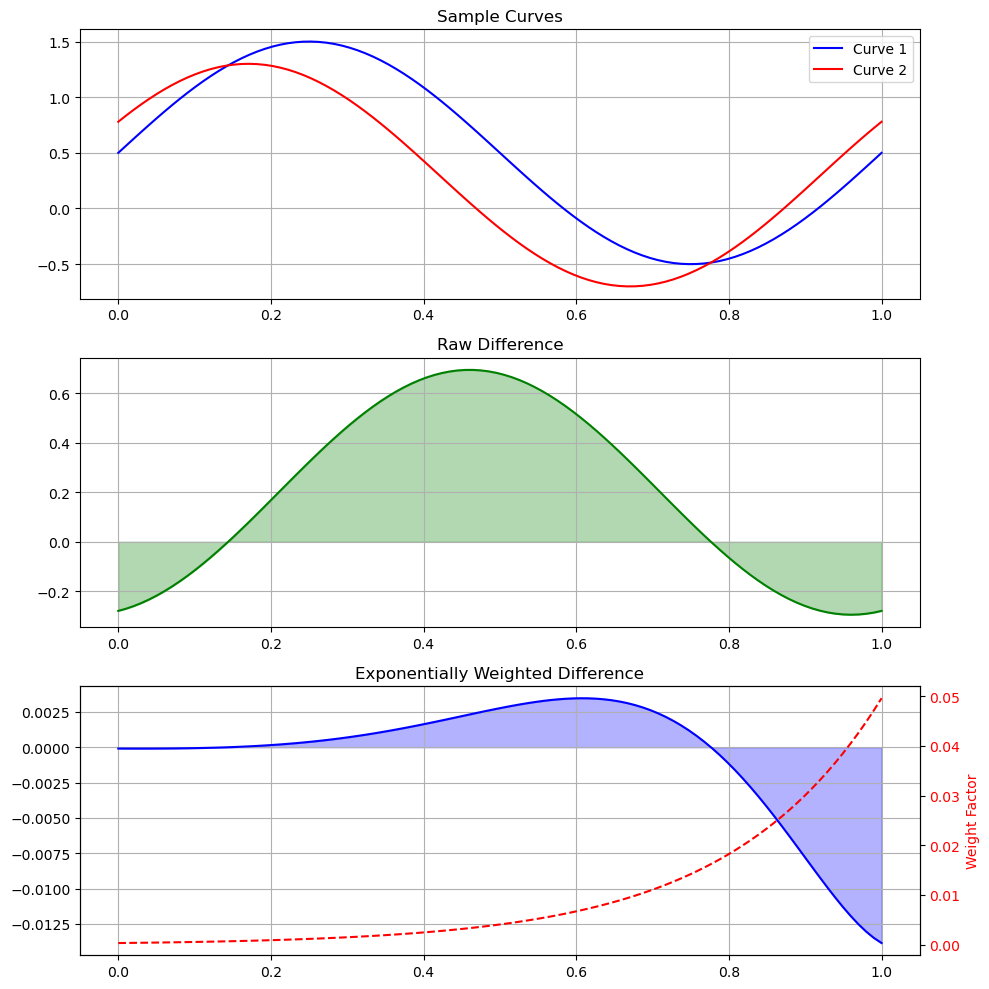

In [8]:
x = np.linspace(0, 1, 100)
y1 = np.sin(2 * np.pi * x) + 0.5
y2 = np.sin(2 * np.pi * x + 0.5) + 0.3

# Define exponential weight function
def exp_weight(x, alpha=5.0):
    return np.exp(alpha * x)

# Calculate the differences
exp_diff = exponentially_weighted_difference(x, y1, y2, alpha=5.0)
area_diff = weighted_area_difference(x, y1, y2, 
                                    weight_func=lambda x: exp_weight(x, alpha=5.0))

# Print results
print(f"Exponentially Weighted Difference: {exp_diff:.6f}")
print(f"Exponentially Weighted Area Difference: {area_diff:.6f}")

# Visualize the curves and weights
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(10, 10))

# Plot curves
ax1.plot(x, y1, 'b-', label='Curve 1')
ax1.plot(x, y2, 'r-', label='Curve 2')
ax1.set_title('Sample Curves')
ax1.legend()
ax1.grid(True)

# Plot differences
diff = y1 - y2
ax2.plot(x, diff, 'g-')
ax2.fill_between(x, 0, diff, alpha=0.3, color='g')
ax2.set_title('Raw Difference')
ax2.grid(True)

# Plot weighted differences
weights = exp_weight(x)
weights_norm = weights / np.sum(weights)
weighted_diff = diff * weights_norm

ax3.plot(x, weighted_diff, 'b-', label='Weighted Difference')
ax3.fill_between(x, 0, weighted_diff, alpha=0.3, color='b')

# Add weight function on secondary y-axis
ax3_twin = ax3.twinx()
ax3_twin.plot(x, weights_norm, 'r--', label='Weight Factor')
ax3_twin.set_ylabel('Weight Factor', color='r')
ax3_twin.tick_params(axis='y', labelcolor='r')

ax3.set_title('Exponentially Weighted Difference')
ax3.grid(True)

plt.tight_layout()
plt.show()

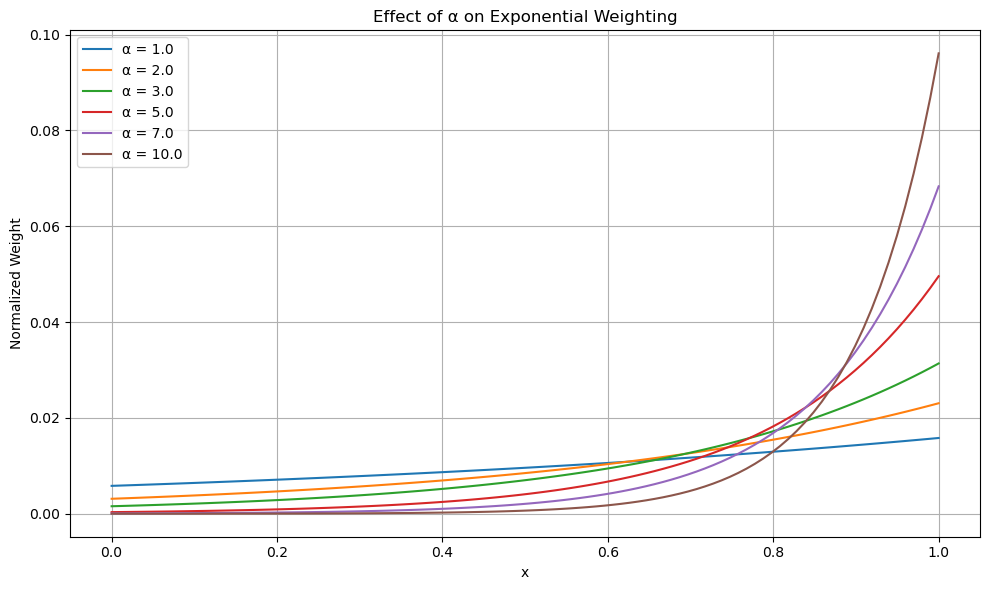

In [9]:
# Create a figure to show how alpha affects the weighting
plt.figure(figsize=(10, 6))
alphas = [1.0, 2.0, 3.0, 5.0, 7.0, 10.0]
for alpha in alphas:
    weights = exp_weight(x, alpha)
    weights_norm = weights / np.sum(weights)
    plt.plot(x, weights_norm, label=f'α = {alpha}')

plt.title('Effect of α on Exponential Weighting')
plt.xlabel('x')
plt.ylabel('Normalized Weight')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

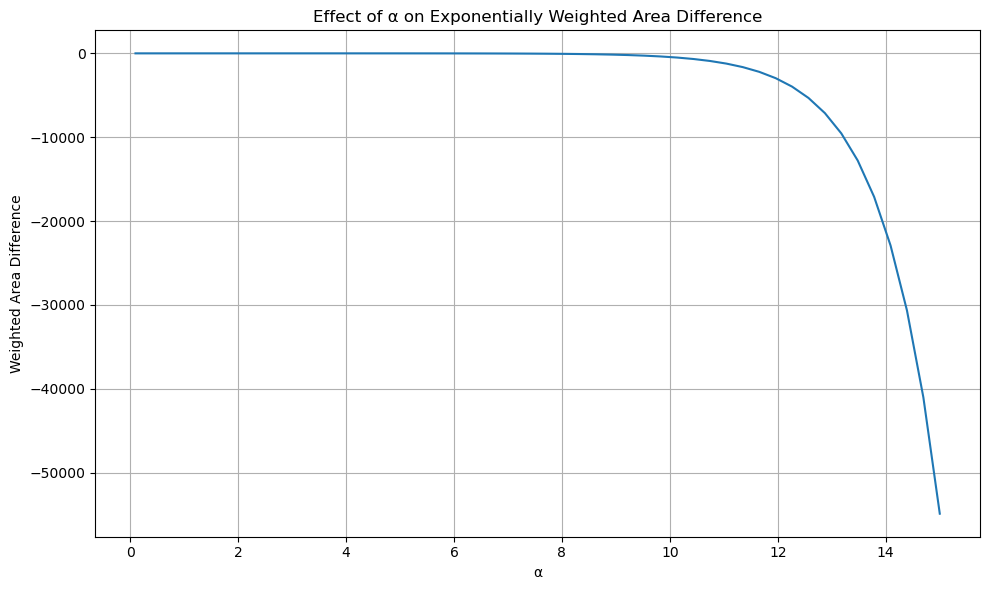

In [10]:
# Create a figure to show how alpha affects the weighted area difference
plt.figure(figsize=(10, 6))
alpha_range = np.linspace(0.1, 15, 50)
area_diffs = []

for alpha in alpha_range:
    area = weighted_area_difference(x, y1, y2, 
                                    weight_func=lambda x, a=alpha: exp_weight(x, a))
    area_diffs.append(area)

plt.plot(alpha_range, area_diffs)
plt.title('Effect of α on Exponentially Weighted Area Difference')
plt.xlabel('α')
plt.ylabel('Weighted Area Difference')
plt.grid(True)
plt.tight_layout()
plt.show()